
1.1 Generate data point

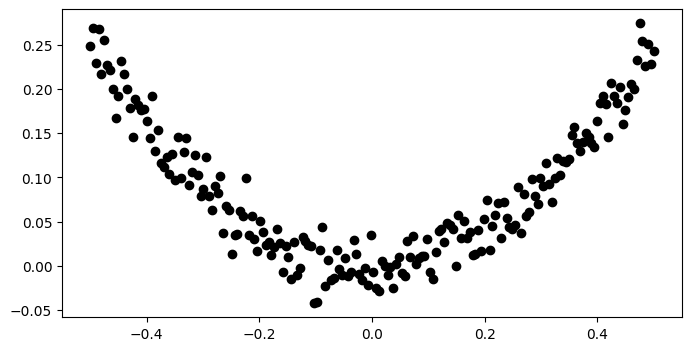

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial
from scipy.constants import degree
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# generation of the datapoint
x_data = np.linspace(-0.5, 0.5, 200)[:, np.newaxis]
noise = np.random.normal(0, 0.02, x_data.shape)
y_data = np.square(x_data) + noise
plt.figure(figsize=(8, 4))
plt.scatter(
    x_data,
    y_data,
    c='black'
)


Apply linear regression:
I expect a large error, the function is polynomial grade 2, x and y are highly scorrelated

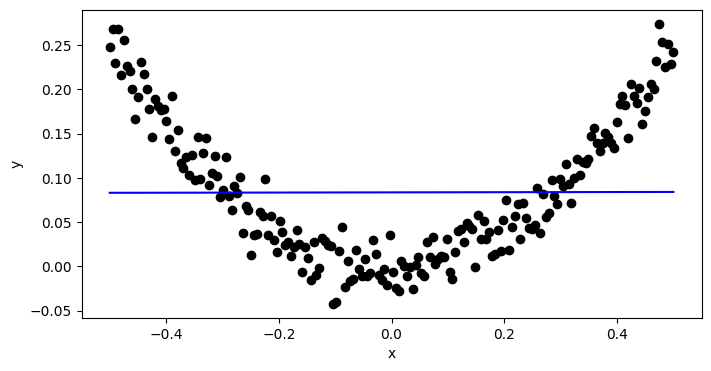

In [23]:
lin_reg=LinearRegression()
lin_reg.fit(x_data,y_data)
lin_predictions = lin_reg.predict(x_data)
plt.figure(figsize=(8, 4))
plt.scatter(
    x_data,
    y_data,
    c='black'
)
plt.plot(
    x_data,
    lin_predictions,
    c='blue',
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Apply a polynomial model with highest power of 2 to predict y data :
I expect that this model whill predict well the dataset

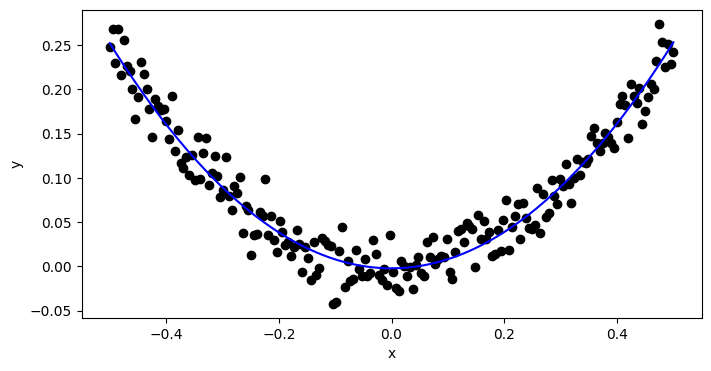

In [24]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

pol_reg = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
pol_reg.fit(x_data, y_data)
pol_predictions = pol_reg.predict(x_data)
plt.figure(figsize=(8, 4))
plt.scatter(
    x_data,
    y_data,
    c='black'
)
plt.plot(
    x_data,
    pol_predictions,
    c='blue',
)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Establish a three-layer (including input, 1 hidden (6 nodes) and output layer) neural network to
predict y data (keras or tensorflow is recommended). Split the dataset into training 80% and
testing data 20% using the following code in Python:

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0000e+00 - loss: 0.0199  
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0000e+00 - loss: 0.0164 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.0135 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: 0.0112 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0000e+00 - loss: 0.0092 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0000e+00 - loss: 0.0077 
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: 0.0065 
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.0055 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: 0.0047 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.0039 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0000e+00 - loss: 0.0033 
Epoch 12/100
5/5 ━━━━━━━━━━━━

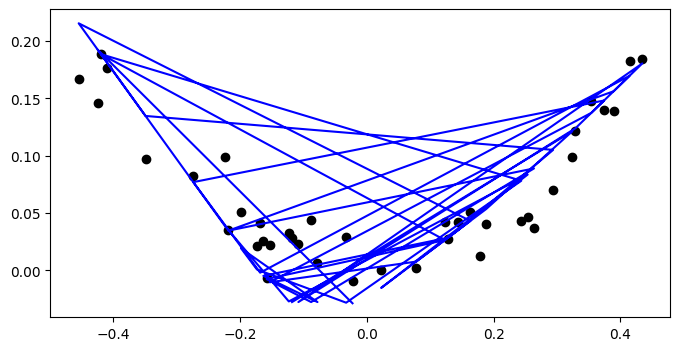

In [25]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential

#split the  data
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.2, random_state=42)


#build neural network
ann=Sequential()
ann.add(tf.keras.layers.Dense(6,activation='relu'))
ann.add(tf.keras.layers.Dense(1,activation='linear'))
ann.compile(loss='mean_squared_error',optimizer='adam',metrics=['accuracy'])

ann.fit(x_train,y_train,epochs=100)
ann_prediction=ann.predict(x_test)
plt.figure(figsize=(8, 4))
plt.scatter(
    x_test,
    y_test,
    c='black'
)
plt.plot(
    x_test,
    ann_prediction,
    c='blue',
)


Calculate and compare mean squared errors of three models in 1.1 (a), (b) and (c)

In [26]:
from sklearn.metrics import mean_squared_error

mse_linear = mean_squared_error(y_data,lin_predictions)
mse_polynomial = mean_squared_error(y_data,pol_predictions)
mse_ann = mean_squared_error(y_test,ann_prediction)

print(f"Mean Squared Error of the linear model: {mse_linear:.6f} of the polinomial model: {mse_polynomial:.6f} of the ANN model: {mse_ann:.6f}")


Mean Squared Error of the linear model: 0.006286 of the polinomial model: 0.000387 of the ANN model: 0.001101
